# Chapter 6. 실전 데이터셋으로 양자 모델 훈련하기

## Training a Quantum Model on a Real Dataset

이 튜토리얼에서는 실제 데이터셋(Dataset)을 사용하여 양자 머신러닝(Quantum Machine Learning) 모델을 학습하는 방법을 소개한다. 이전 튜토리얼들은 작은 인공 데이터셋을 다루었지만, 여기서는 현실의 고전 데이터셋을 고려하여 문제의 복잡도를 높인다. 우리는 매우 잘 알려진 – 하지만 여전히 상대적으로 작은 – 문제인 아이리스 꽃 데이터셋(Iris Flower Dataset)을 선택했다. 이 데이터셋은 위키피디아 페이지(https://en.wikipedia.org/wiki/Iris_flower_data_set)도 가지고 있다. 아이리스 데이터셋은 데이터 과학자들에게 잘 알려져 있지만, 우리는 기억을 되살리기 위해 간략하게 소개하겠다. 비교를 위해 먼저 고전 모델(Classical Model)을 사용하여 양자 모델의 고전적 대응물을 학습한다.

그러면 시작해보자:

- 먼저 데이터셋을 로드하고 어떻게 보이는지 탐색한다.
- 다음으로, scikit-learn의 SVC(Support Vector Classifier, 지지 벡터 분류기)를 사용하여 고전 모델을 학습하여 고전적 방법으로 분류 문제를 얼마나 잘 해결할 수 있는지 확인한다.
- 그 후, 변분 양자 분류기(Variational Quantum Classifier, VQC)를 소개한다.
- 결론으로, 두 모델에서 얻은 결과를 비교한다.

## 1. 탐색적 데이터 분석 (Exploratory Data Analysis)

먼저 이 튜토리얼에서 사용할 아이리스 데이터셋(Iris Dataset)을 탐색하고 포함된 내용을 확인해보자. 편의상 이 데이터셋은 scikit-learn에서 사용 가능하며 쉽게 로드할 수 있다.

In [1]:
# 아이리스 데이터셋(Iris Dataset) 로드 — 사이킷런(Scikit-learn) 내장 데이터셋
from sklearn.datasets import load_iris

iris_data = load_iris()

load_iris 함수에 매개변수(Parameter)를 지정하지 않으면, scikit-learn은 사전(Dictionary) 형태의 객체를 반환한다. 데이터셋의 설명(Description)을 출력하고 내부에 무엇이 있는지 확인해보자.

In [2]:
# 데이터셋(Dataset)의 상세한 설명(Description) 출력
print(iris_data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

이 데이터셋 설명(Description)에서 몇 가지 흥미로운 관찰(Observation)을 할 수 있다:

- 데이터셋에는 150개의 샘플(Sample, 인스턴스)이 있다.
- 각 샘플에는 4개의 특성(Feature, 속성)이 있다.
- 데이터셋에는 3개의 레이블(Label, 클래스)이 있다.
- 데이터셋은 완벽하게 균형잡혀 있으며, 각 클래스에 같은 수(50개)의 샘플이 있다.
- 특성들은 정규화되지 않았으며, 값의 범위가 다르다. 예를 들어, 꽃받침 길이는 [4.3, 7.9]이고 꽃잎 너비는 [0.1, 2.5]이다. 따라서 특성을 같은 스케일로 변환하는 것이 도움이 될 수 있다.
- 위 표에서 보이듯이, 일부 특성-클래스 상관관계(Correlation)는 매우 높다. 이는 우리 모델이 데이터셋을 잘 처리해야 한다고 생각하도록 할 수 있다.

우리는 데이터셋 설명만 검토했지만, iris_data 객체에는 추가 속성들이 있다. 이제 우리는 데이터셋에서 특성(Feature)과 레이블(Label)을 사용하여 작업하겠다.

In [3]:
# 데이터셋에서 특성(Feature)과 레이블(Label) 추출
features = iris_data.data
labels = iris_data.target

먼저 특성(Feature)을 정규화(Normalization)하겠다. 즉, 모든 특성을 같은 스케일로 표현하기 위해 간단한 변환을 적용한다. 우리의 경우, 모든 특성을 구간 [0, 1]로 압축한다. 정규화(Normalization)는 머신러닝에서 일반적인 기법이며, 종종 알고리즘의 수치 안정성(Numerical Stability)과 수렴(Convergence)을 개선한다.

scikit-learn의 MinMaxScaler를 사용하여 이를 수행할 수 있다. 매개변수를 지정하지 않으면, 이는 정확히 필요한 것을 수행한다: 데이터를 [0, 1]로 매핑한다.

In [4]:
# 최솟값-최댓값 스케일러(MinMaxScaler)를 사용하여 특성값을 [0, 1] 범위로 정규화(Normalization)
from sklearn.preprocessing import MinMaxScaler

features = MinMaxScaler().fit_transform(features)

우리의 데이터가 어떻게 보이는지 확인해보겠다. 특성들을 쌍으로 플롯하여 그들 사이에 관찰 가능한 상관관계(Correlation)가 있는지 확인한다.

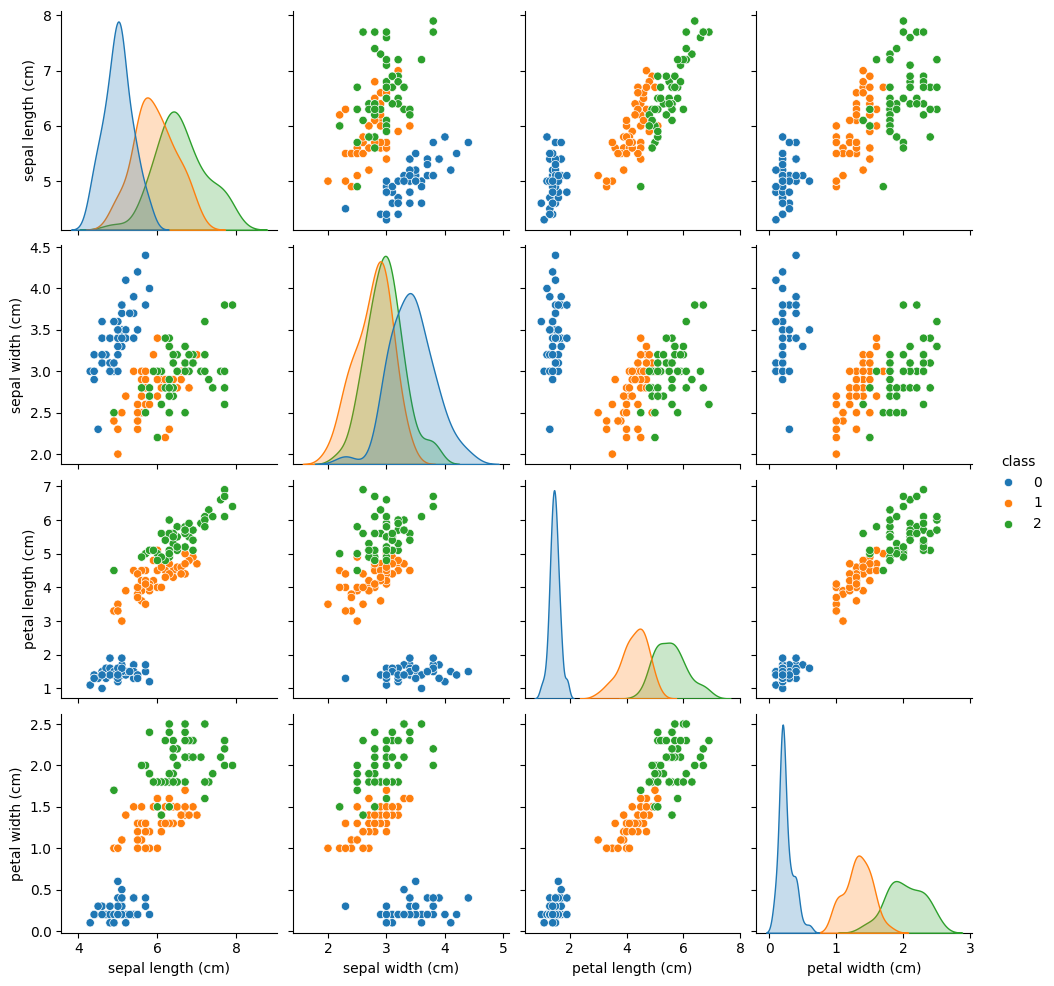

In [5]:
# 판다스 데이터프레임(Pandas DataFrame)으로 변환 후 특성(Feature) 간 쌍별 플롯(Pairplot) 시각화(Visualization)
# 각 클래스(Class)를 다른 색상으로 표시
import pandas as pd
import seaborn as sns

df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df["class"] = pd.Series(iris_data.target)

sns.pairplot(df, hue="class", palette="tab10")

플롯에서 클래스(Class) 0은 나머지 두 클래스와 쉽게 분리 가능(Separable)하지만, 클래스 1과 2는 특히 "꽃받침 너비(Sepal Width)" 특성과 관련하여 때때로 얽혀 있다.

다음으로, 고전 머신러닝이 이 데이터셋을 어떻게 처리하는지 확인해보자.

## 2. 고전 머신러닝(Classical Machine Learning) 모델 훈련하기

모델을 훈련하기 전에, 데이터셋을 두 부분으로 나누어야 한다: 훈련 데이터셋(Training Dataset)과 테스트 데이터셋(Test Dataset). 전자는 모델을 훈련하는 데 사용하고, 후자는 우리의 모델이 보지 못한 데이터(Unseen Data)에서 얼마나 잘 수행하는지 확인하는 데 사용한다.

평소처럼, scikit-learn에 지루한 작업을 요청한다. 또한 결과의 재현성(Reproducibility)을 보장하기 위해 시드를 고정한다.

In [6]:
# 재현성(Reproducibility)을 위한 랜덤 시드(Random Seed) 설정
# 학습/테스트(Train/Test) 데이터셋 분할 — 80% 학습(Train), 20% 테스트(Test)
from sklearn.model_selection import train_test_split
from qiskit_machine_learning.utils import algorithm_globals

algorithm_globals.random_seed = 123
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, random_state=algorithm_globals.random_seed
)

scikit-learn에서 고전 지지 벡터 분류기(Support Vector Classifier, SVC)를 훈련한다. 단순성을 위해 매개변수를 조정하지 않고 기본값에 의존한다.

In [7]:
# 사이킷런(Scikit-learn)의 지지 벡터 분류기(Support Vector Classifier, SVC) 생성 및 학습(Training)
from sklearn.svm import SVC

svc = SVC()
_ = svc.fit(train_features, train_labels)  # suppress printing the return value

이제 고전 모델(Classical Model)의 성능(Performance)을 확인한다. 우리는 결론 섹션에서 점수를 분석할 것이다.

In [8]:
# 고전 모델(Classical Model)의 학습(Train) 및 테스트(Test) 성능(Performance) 평가
train_score_c4 = svc.score(train_features, train_labels)
test_score_c4 = svc.score(test_features, test_labels)

print(f"Classical SVC on the training dataset: {train_score_c4:.2f}")
print(f"Classical SVC on the test dataset:     {test_score_c4:.2f}")

Classical SVC on the training dataset: 0.99
Classical SVC on the test dataset:     0.97


보시다시피, 고전 SVC 알고리즘(Algorithm)의 성능이 매우 좋다. 이제 양자 머신러닝 모델들을 살펴볼 차례이다.

## 3. 양자 머신러닝(Quantum Machine Learning) 모델 훈련하기

양자 모델의 예로서, 우리는 변분 양자 분류기(Variational Quantum Classifier, VQC)를 훈련할 것이다. VQC는 Qiskit Machine Learning에서 사용 가능한 가장 간단한 분류기이며, 고전 머신러닝 배경을 가진 양자 머신러닝 초보자들을 위한 좋은 출발점이다.

하지만 모델을 훈련하기 전에, VQC 클래스가 무엇으로 구성되어 있는지 살펴보자. 그 중 두 가지 중요한 요소는 특성 맵(Feature Map)과 안자츠(Ansatz)이다. 이것들이 무엇인지 이제 설명하겠다.

우리의 데이터는 고전적이며, 이는 비트 세트로 구성되어 있고, 큐비트로 구성되지 않는다. 데이터를 큐비트로 인코딩(Encoding)하는 방법이 필요하다. 이 과정은 효과적인 양자 모델을 원한다면 매우 중요하다. 우리는 보통 이 매핑을 데이터 인코딩(Data Encoding), 데이터 임베딩(Data Embedding), 또는 데이터 로딩(Data Loading)이라고 부르며, 이것이 특성 맵(Feature Map)의 역할이다. 특성 맵핑(Feature Mapping)은 일반적인 머신러닝 메커니즘이지만, 데이터를 양자 상태(Quantum State)에 로드하는 이 과정은 고전 세계에서만 작동하는 고전 머신러닝에는 나타나지 않는다.

데이터가 로드되면, 우리는 즉시 매개변수화된 양자 회로(Parameterized Quantum Circuit)를 적용해야 한다. 이 회로는 고전 신경망의 계층(Layer)에 직접 유사하다. 그것은 조정 가능한 매개변수(Tunable Parameter) 또는 가중치(Weight) 세트를 가지고 있다. 가중치는 목적 함수(Objective Function)를 최소화하도록 최적화된다. 이 목적 함수는 예측과 알려진 레이블 데이터 사이의 거리(Distance)를 특징짓는다. 매개변수화된 양자 회로는 또한 매개변수화된 시행 상태(Parameterized Trial State), 변분 형태(Variational Form), 또는 안자츠(Ansatz)라고도 불린다. 아마도 후자가 가장 널리 사용되는 용어이다.

더 많은 정보는 Quantum Machine Learning Course GitHub(https://github.com/Qiskit/textbook/tree/main/notebooks/quantum-machine-learning#)로 독자를 안내한다.

우리의 특성 맵(Feature Map) 선택은 ZZ 특성 맵(ZZ Feature Map)이 될 것이다. zz_feature_map은 Qiskit 회로 라이브러리에서 표준 특성 맵 회로 중 하나이다. 우리는 num_features를 feature_dimension으로 전달하며, 이는 특성 맵이 num_features 또는 4개의 큐비트를 가질 것을 의미한다.

우리는 특성 맵(Feature Map)을 구성 게이트(Constituent Gate)로 분해하여 특성 맵이 어떻게 보일 수 있는지 독자에게 맛을 제공한다.

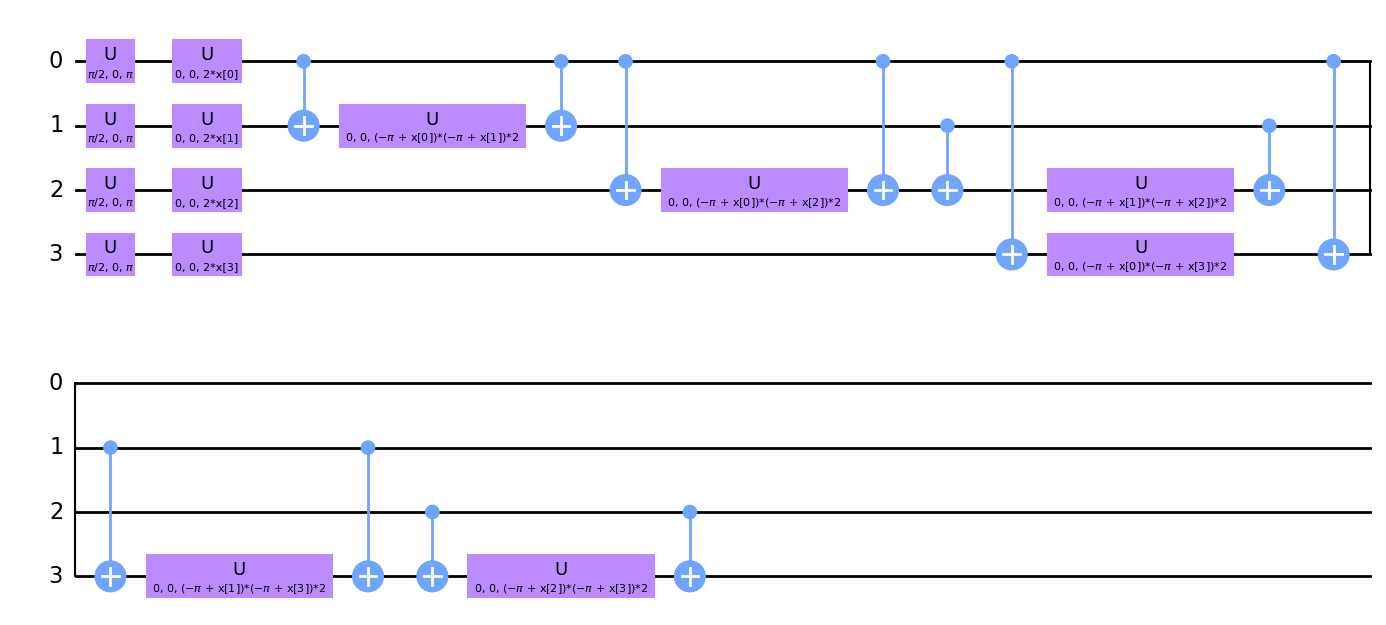

In [9]:
# ZZ 특성 맵(ZZ Feature Map) 생성 — 특성(Feature) 데이터를 양자 상태(Quantum State)로 인코딩(Encoding)
# 특성 차원(Feature Dimension) = 큐비트(Qubit) 수 = 4
from qiskit.circuit.library import zz_feature_map

num_features = features.shape[1]

feature_map = zz_feature_map(feature_dimension=num_features, reps=1)
feature_map.decompose().draw(output="mpl", style="clifford", fold=20)

피처 맵(Feature Map) 다이어그램을 자세히 살펴보면, 매개변수 x[0], ..., x[3]을 알아차릴 것이다. 이들은 우리의 특성(Feature)에 대한 플레이스홀더(Placeholder)이다.

이제 우리는 우리의 안자츠(Ansatz)를 생성하고 플롯한다. 안자츠 회로의 반복적인 구조에 주목하라. 우리는 reps 매개변수(Parameter)를 사용하여 이 반복 수를 정의한다.

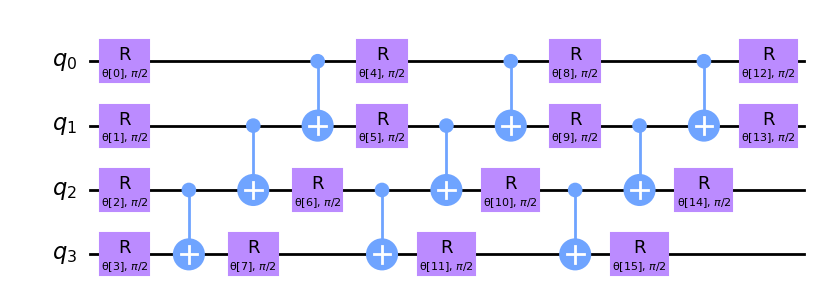

In [10]:
# 실진폭 안자츠(RealAmplitudes Ansatz) 생성 — 학습 가능한 매개변수(Trainable Parameter)를 갖는 양자 회로(Quantum Circuit)
# num_qubits=4, reps=3 → 총 16개의 학습 가능한 매개변수(Parameter)
from qiskit.circuit.library import real_amplitudes

ansatz = real_amplitudes(num_qubits=num_features, reps=3)
ansatz.decompose().draw(output="mpl", style="clifford", fold=20)

이 회로는 θ[0], ..., θ[15]로 명명된 16개의 매개변수(Parameter)를 가지고 있다. 이들은 분류기의 훈련 가능한 가중치(Trainable Weight)이다.

그 다음 훈련 과정에서 사용할 최적화 알고리즘(Optimization Algorithm)을 선택한다. 이 단계는 고전 딥러닝 프레임워크에서 찾을 수 있는 것과 유사하다. 훈련 프로세스를 더 빠르게 하기 위해, 우리는 기울기 없는 최적화기(Gradient-Free Optimizer)를 선택한다. 당신은 Qiskit에서 사용 가능한 다른 최적화기를 탐색할 수 있다.

In [11]:
# COBYLA 최적화기(Optimizer) 생성 — 기울기 불필요(Gradient-Free) 최적화기
# 최대 100번의 반복(Iteration)으로 최적화(Optimization)
from qiskit_machine_learning.optimizers import COBYLA

optimizer = COBYLA(maxiter=100)

다음 단계에서 우리는 분류기를 훈련할 장소를 정의한다. 우리는 시뮬레이터(Simulator) 또는 실제 양자 컴퓨터에서 훈련할 수 있다. 여기서 우리는 시뮬레이터를 사용할 것이다. 우리는 qiskit.primitives의 StatevectorSampler 인스턴스에서 Sampler 원시 타입(Primitive)의 인스턴스를 생성한다. 이것은 상태벡터(Statevector) 기반의 참조 구현(Reference Implementation)이다. qiskit runtime 서비스(Service)를 사용하여 양자 컴퓨터로 지원되는 샘플러를 생성할 수 있다.

In [12]:
# 상태 벡터 샘플러(StatevectorSampler) 인스턴스 생성 — 상태벡터(Statevector) 기반 시뮬레이션
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

우리는 callback_graph라는 콜백 함수(Callback Function)를 추가한다. VQC는 이 함수를 목적 함수(Objective Function)의 각 평가(Evaluation)마다 두 개의 매개변수(Parameter)로 호출한다: 현재 가중치(Weight)와 그 가중치에서의 목적 함수 값(Value)이다. 우리의 콜백은 목적 함수의 값을 배열에 추가하여 반복(Iteration) 대 목적 함수 값을 플롯할 수 있다. 콜백은 각 반복(Iteration)에서 플롯을 업데이트한다. 콜백 함수 내에서 우리가 언급한 두 매개변수 시그니처(Signature)를 가지고 있다면 뭐든 할 수 있다는 점에 유의하라.

In [13]:
# 학습 과정의 목적 함수(Objective Function) 값을 실시간 시각화하는 콜백 함수(Callback Function) 설정
from matplotlib import pyplot as plt
from IPython.display import clear_output

objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)


def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

이제 분류기를 구성하고 학습할 준비가 되었다.

VQC는 "변분 양자 분류기(Variational Quantum Classifier)"를 의미한다. 특성 맵(Feature Map)과 안자츠(Ansatz)를 가져와서 자동으로 양자 신경망(Quantum Neural Network)을 구성한다. 가장 간단한 경우, 큐비트 수와 양자 인스턴스를 전달하여 유효한 분류기를 구성하는 것만으로도 충분하다. 당신은 sampler 매개변수를 생략할 수 있으며, 이 경우 우리가 앞서 생성한 방식으로 Sampler 인스턴스가 당신을 위해 생성될 것이다. 우리는 설명 목적으로만 수동으로 생성했다.

훈련은 시간이 걸릴 수 있다. 기다려 주길 바란다.

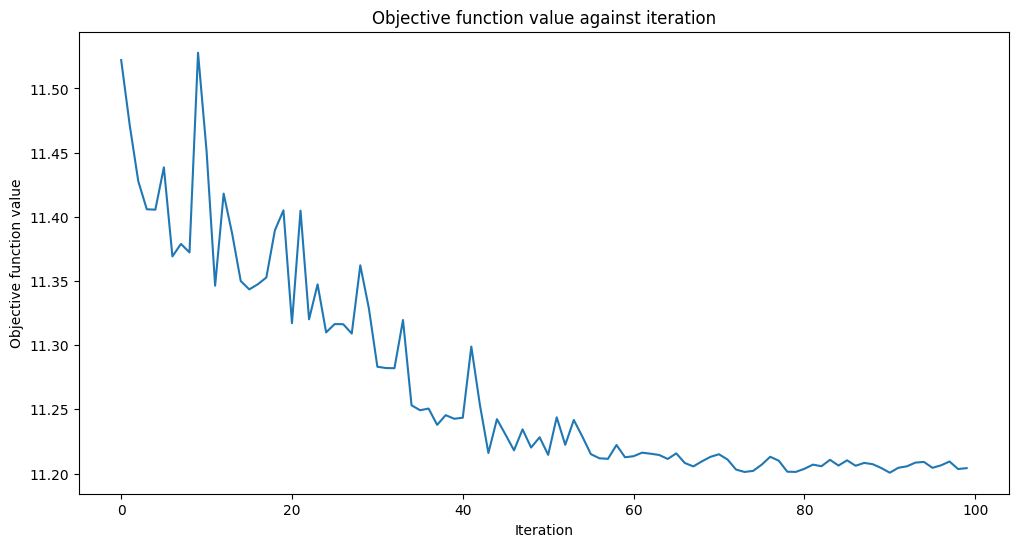

Training time: 24 seconds


In [14]:
# 변분 양자 분류기(Variational Quantum Classifier, VQC) 생성 및 학습(Training)
# 학습 시간(Training Time) 측정
import time
from qiskit_machine_learning.algorithms.classifiers import VQC

vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

# clear objective value history
objective_func_vals = []

start = time.time()
vqc.fit(train_features, train_labels)
elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")

양자 모델(Quantum Model)의 성능(Performance)을 확인해보겠다.

In [15]:
# 양자 모델(Quantum Model)의 학습(Train) 및 테스트(Test) 성능(Performance) 평가
train_score_q4 = vqc.score(train_features, train_labels)
test_score_q4 = vqc.score(test_features, test_labels)

print(f"Quantum VQC on the training dataset: {train_score_q4:.2f}")
print(f"Quantum VQC on the test dataset:     {test_score_q4:.2f}")

Quantum VQC on the training dataset: 0.63
Quantum VQC on the test dataset:     0.53


보시다시피, 점수가 높으며, 이 모델을 사용하여 보지 못한 데이터에 대한 레이블을 예측할 수 있다.

이제 더 나은 모델을 얻기 위해 조정할 수 있는 것들을 확인해보자.

- 핵심 요소는 특성 맵(Feature Map)과 안자츠(Ansatz)이다. 매개변수를 조정할 수 있다. 우리의 경우, reps 매개변수(Parameter)를 변경하여 우리가 회로에 추가하는 게이트 패턴의 반복 횟수를 지정할 수 있다. 더 큰 값은 더 많은 얽힘(Entanglement) 작업과 더 많은 매개변수로 이어진다. 따라서 모델은 더 유연할 수 있지만, 더 많은 매개변수 수는 복잡성을 증가시키고, 그러한 모델을 훈련하는 것은 보통 더 많은 시간이 걸린다. 더욱이, 우리는 모델이 과적합(Overfitting)될 수 있다. 당신은 Qiskit 회로 라이브러리(https://quantum.cloud.ibm.com/docs/api/qiskit/circuit_library#n-local-circuits)에서 사용 가능한 다른 특성 맵과 안자츠를 시도할 수 있거나, 당신만의 커스텀 회로를 생각해낼 수 있다.
- 다른 최적화기(Optimizer)를 시도할 수 있다. Qiskit에는 많은 것들이 포함되어 있다. 일부는 기울기 없는 것이고, 다른 것들은 그렇지 않다. 당신이 기울기 기반 최적화기를 선택한다면, 예를 들어 L_BFGS_B, 훈련 시간이 증가할 것을 예상하라. 목적 함수에 추가로, 이 최적화기들은 훈련 매개변수에 대한 기울기를 평가해야 하며, 이는 반복당 회로 실행 수의 증가로 이어진다.
- 또 다른 옵션은 initial_point를 무작위로(또는 결정적으로) 샘플링하고 모델을 여러 번 맞추는 것이다.

하지만 데이터셋이 현대의 양자 컴퓨터가 처리할 수 있는 것보다 더 많은 특성을 포함한다면? 회상하라, 이 예에서 우리는 데이터셋의 특성 수와 같은 수의 큐비트를 가졌지만, 이것이 항상 그럴 수는 없다.

## 4. 특성(Feature) 수 감소하기

이 섹션에서, 우리는 데이터셋의 특성 수를 줄이고 우리의 모델들을 다시 훈련한다. 처음을 제외하고는 단계들이 같기 때문에 이번에는 더 빠르게 진행할 것이며, 우리는 PCA 변환(Transformation)을 적용한다.

우리는 4개의 특성을 2개의 특성으로만 변환한다. 이 차원 축소(Dimensionality Reduction)는 교육적 목적만을 위한 것이다. 이전 섹션에서 보았듯이, 우리는 데이터셋의 모든 4개 특성을 사용하여 양자 모델을 훈련할 수 있다.

이제 우리는 이 2개의 특성을 하나의 그림에 쉽게 플롯할 수 있다.

<Axes: >

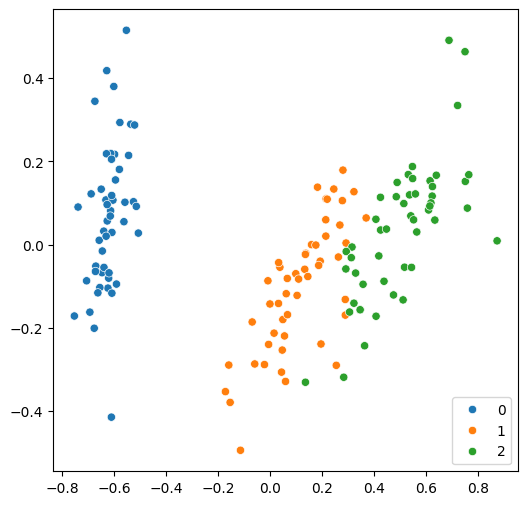

In [16]:
# 주성분 분석(PCA)으로 특성(Feature) 차원 축소(Dimensionality Reduction): 4차원 → 2차원
# 축소된 데이터를 2D 산점도(Scatter Plot)로 시각화(Visualization)
from sklearn.decomposition import PCA

features = PCA(n_components=2).fit_transform(features)

plt.rcParams["figure.figsize"] = (6, 6)
sns.scatterplot(x=features[:, 0], y=features[:, 1], hue=labels, palette="tab10")

평소처럼, 먼저 데이터셋을 분할하고, 그 다음 고전 모델을 맞춘다.

In [17]:
# 2개 특성(Feature)으로 데이터셋(Dataset) 재분할 후 고전 지지 벡터 분류기(SVC) 재학습(Training)
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, random_state=algorithm_globals.random_seed
)

svc.fit(train_features, train_labels)

train_score_c2 = svc.score(train_features, train_labels)
test_score_c2 = svc.score(test_features, test_labels)

print(f"Classical SVC on the training dataset: {train_score_c2:.2f}")
print(f"Classical SVC on the test dataset:     {test_score_c2:.2f}")

Classical SVC on the training dataset: 0.97
Classical SVC on the test dataset:     0.90


결과는 여전히 좋지만 초기 버전보다 약간 낮다. 양자 모델이 어떻게 처리하는지 확인해보자. 이제 2개의 큐비트가 있으므로, 특성 맵(Feature Map)과 안자츠(Ansatz)를 다시 생성해야 한다.

In [18]:
# 2개 큐비트(Qubit)에 맞춰 특성 맵(Feature Map)과 안자츠(Ansatz) 재생성
num_features = features.shape[1]

feature_map = zz_feature_map(feature_dimension=num_features, reps=1)
ansatz = real_amplitudes(num_qubits=num_features, reps=3)

또한 우리는 최적화 프로세스를 실행할 최대 반복 횟수(Max Iterations)를 줄인다. 이제 더 적은 큐비트(Qubit)가 있기 때문에 더 빠른 수렴(Convergence)을 예상한다.

In [19]:
# 적은 큐비트(Qubit)로 더 빠른 수렴(Convergence)을 위해 최적화 반복 횟수(Iteration) 감소
optimizer = COBYLA(maxiter=40)

이제 새로운 매개변수로 양자 분류기를 구성하고 훈련한다.

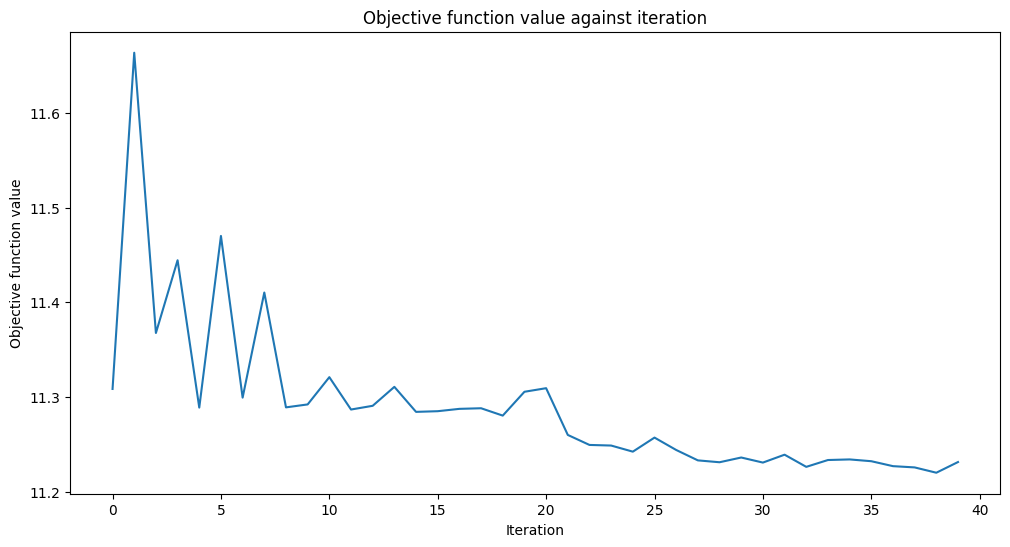

Training time: 7 seconds


In [20]:
# 2개 특성(Feature)으로 변분 양자 분류기(VQC) 생성 및 학습(Training)
vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

# clear objective value history
objective_func_vals = []

# make the objective function plot look nicer.
plt.rcParams["figure.figsize"] = (12, 6)


start = time.time()
vqc.fit(train_features, train_labels)
elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")

In [21]:
# 2개 특성(Feature), 실진폭 안자츠(RealAmplitudes Ansatz) 모델의 성능(Performance) 평가
train_score_q2_ra = vqc.score(train_features, train_labels)
test_score_q2_ra = vqc.score(test_features, test_labels)

print(f"Quantum VQC on the training dataset using real_amplitudes: {train_score_q2_ra:.2f}")
print(f"Quantum VQC on the test dataset using real_amplitudes:     {test_score_q2_ra:.2f}")

Quantum VQC on the training dataset using real_amplitudes: 0.55
Quantum VQC on the test dataset using real_amplitudes:     0.47


점수가 동전 던지기(Coin Toss)보다는 높지만 개선 여지가 있다. 목적 함수는 끝을 향해 거의 평평하며, 이는 반복 횟수를 증가시킨다고 해도 도움이 되지 않을 것이며, 모델 성능은 같을 것임을 의미한다. 다른 안자츠(Ansatz)로 무엇을 할 수 있는지 확인해보자.

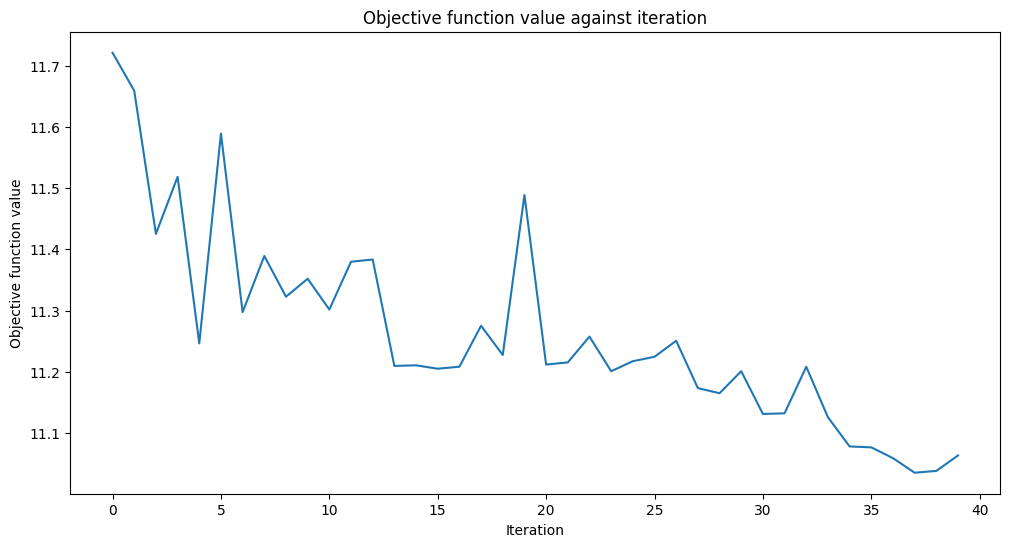

Training time: 8 seconds


In [22]:
# 효율적 SU2 안자츠(EfficientSU2 Ansatz)로 변경하여 성능 개선 시도
# 새로운 안자츠(Ansatz)와 최적화기(Optimizer)로 변분 양자 분류기(VQC) 생성 및 학습(Training)
from qiskit.circuit.library import efficient_su2

ansatz = efficient_su2(num_qubits=num_features, reps=3)
optimizer = COBYLA(maxiter=40)

vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

# clear objective value history
objective_func_vals = []

start = time.time()
vqc.fit(train_features, train_labels)
elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")

In [23]:
# 2개 특성(Feature), 효율적 SU2 안자츠(EfficientSU2 Ansatz) 모델의 성능(Performance) 평가
train_score_q2_eff = vqc.score(train_features, train_labels)
test_score_q2_eff = vqc.score(test_features, test_labels)

print(f"Quantum VQC on the training dataset using efficient_su2: {train_score_q2_eff:.2f}")
print(f"Quantum VQC on the test dataset using efficient_su2:     {test_score_q2_eff:.2f}")

Quantum VQC on the training dataset using efficient_su2: 0.63
Quantum VQC on the test dataset using efficient_su2:     0.63


EfficientSU2 안자츠(Ansatz)를 사용한 결과가 더 낫다. 아마도 더 많은 반복을 사용했다면, 우리는 더 잘할 수 있었을 것이다.

## 5. 결론

이 튜토리얼에서 2개의 고전 모델과 3개의 양자 모델을 구축했다. 결과와 함께 전체 테이블을 출력해보자.

In [24]:
# 모든 모델(Model)의 학습(Train)/테스트(Test) 성능을 비교하는 결과 테이블(Result Table) 출력
print(f"Model                            | Test Score | Train Score")
print(f"SVC, 4 features                  | {train_score_c4:10.2f} | {test_score_c4:10.2f}")
print(f"VQC, 4 features, real_amplitudes | {train_score_q4:10.2f} | {test_score_q4:10.2f}")
print(f"-----------------------------------------------------------")
print(f"SVC, 2 features                  | {train_score_c2:10.2f} | {test_score_c2:10.2f}")
print(f"VQC, 2 features, real_amplitudes | {train_score_q2_ra:10.2f} | {test_score_q2_ra:10.2f}")
print(f"VQC, 2 features, efficient_su2   | {train_score_q2_eff:10.2f} | {test_score_q2_eff:10.2f}")

Model                            | Test Score | Train Score
SVC, 4 features                  |       0.99 |       0.97
VQC, 4 features, real_amplitudes |       0.63 |       0.53
-----------------------------------------------------------
SVC, 2 features                  |       0.97 |       0.90
VQC, 2 features, real_amplitudes |       0.55 |       0.47
VQC, 2 features, efficient_su2   |       0.63 |       0.63


In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright